<a href="https://colab.research.google.com/github/solivagvs/stat554hw05/blob/main/sandorHW05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student: Bryan Sandor**

**Stat 554**

**Homework 05**

# Part I - Concepts

## Question 1

Like many individuals, I concern myself with the weather. The National Oceanic and Atmospheric Administration (NOAA), among other entities, collects a surfeit of data to make decisions regarding forecasts to one of its appendant bodies, the National Weather Service (NWS).
- Volume: The agency must collect a variety of data per sensor measuring things such as barometric pressure, temperature, humidity, light, air quality, etc.
- Velocity: These conditions change by the second and the NWS relies on up-to-date information in order to make more accurate predictions.
- Variety: Many subsidiary agencies exist to furnish the NWS with supplementary data, including that they collect theirself.
- Veracity: The more accurate the data collected, presumably the better a forecast the NWS can make.
- Value: Data collected and predictions made help inform future forecasts and increase reliability.

## Question 2

- **C**reate: After connecting to the database, we create a local data frame instance to peruse the data. Furthermore, we create a new column using the existing data, in the last step, to return the win/loss percentages.
- **R**ead: We read the data several different times, subject to different specified conditions.
- **U**pdate: I don't see a case where the database is updated apart from creating a win/loss variable and "updating" it using existing data.
- **D**elete: By closing the connection to the database, the local data frame is purged from memory upon disconnecting from the Google Colab server.

## Question 3

When using the `SELECT` statement, data may be grouped using the `GROUP BY` command specifically subject to the optional `HAVING` clause.

# Part II - Simulation of a Sampling Distribution

We first use the supplied code to generate random data from a simple linear regression (SLR) model $$Y_i = \beta_0 + \beta_1 x_i + E_i$$ where the $E_i$ are indepedent and identically distributed (iid) from $N(0, \sigma^2 = 1)$. This data is generated by assuming values for $\beta_0$, $\beta_1$, $n$, and a sequence of $x$ values:

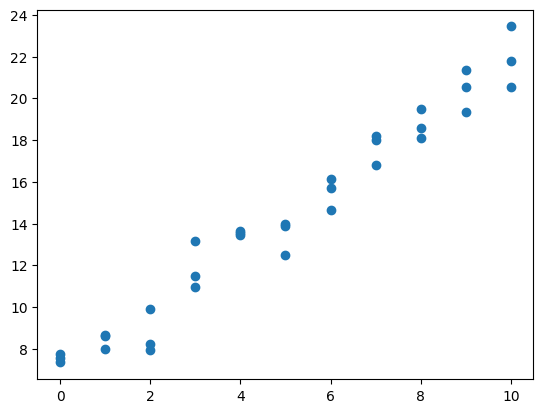

In [1]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng

rng = default_rng(999)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1 * x + rng.standard_normal(n)

#visualize the data
plt.scatter(x = x, y = y)
plt.show()

Now we perform regression on the 33 generated values to find an estimate for the slope of the SLR, $\hat{\beta_1}$.

In [2]:
from sklearn.linear_model import LinearRegression

x = x.reshape((-1, 1))
reg = LinearRegression().fit(x, y)

LinearRegression()
m = reg.coef_[0]
print(m)

1.4856398973447633


Now we create use a loop to repeat this process and generate 5000 different estimates for the slope.

In [3]:
k = 5000

beta1hat = [0] * k

for i in range(k):
    # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33

    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1 * x + rng.standard_normal(n)

    x = x.reshape((-1, 1))
    reg = LinearRegression().fit(x, y)

    LinearRegression()
    beta1hat[i] = reg.coef_[0]

Now we generate a histogram of the different estimates for $\beta_1$ to examine their distribution.

<Axes: ylabel='Count'>

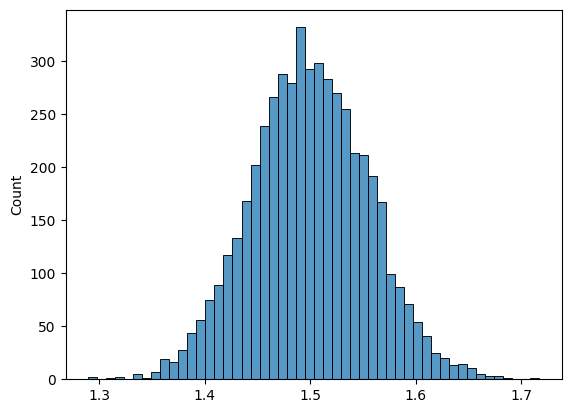

In [4]:
import seaborn as sns

sns.histplot(beta1hat)

Finally, we use the generated values to find the empirical probability $$\mathbb{P}(\hat{\beta_1} > 1.65)$$

In [5]:
probcount = 0

for i in range(k):
    if beta1hat[i] > 1.65:
        probcount += 1

print("The probability beta-1-hat is greater than 1.65 is", \
      round(probcount / k, 4))

The probability beta-1-hat is greater than 1.65 is 0.0046


This probability is much lower than, say, 0.05, so we can say it is statistically significant. In a hypothesis test, we could conclude $\beta_1$ is not greater than 1.65.

# Part III - Big Data Examples & Rare Events

## Question 5

# Part IV - Querying a database

## Question 8

## Question 9

## Question 10

## Question 11

## Question 12

## Question 13